In [35]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt
import math

from os import listdir
from os.path import isfile, join

from utils.data_parsing_tools import get_lot, load_all_locations, data_source_path
from utils.general_tools import pd_to_param_holder
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.modeling_tools import perform_modeling_linear
from utils.regression_tools import forecast_test_linear
from utils.display_tools import load_best_forecasts, display_predictions, display_predictions_2
from utils.general_tools import results_to_pd, param_holder

from utils.data_processing_tools import (
    bring_to_original_range,
    full_preprocessing_pipeline,
)
from utils.regression_tools import score_on_original_range_and_save
import statsmodels.api as sm


In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
data = pd.read_csv("R_base/Moehne_MultiReg.csv")

In [60]:
lot = pickle.load(open("../saves_and_results/cache_lot.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [61]:
data["Date"] = pd.to_datetime(data["Date"])

In [62]:
data = data[data["Date"].dt.year >= 2015]
data = data[data["Date"].dt.year <= 2020]

In [65]:
merge = data.merge(lot["Moehne"]["lot"], left_on="Date", right_index=True, how="left")
merge = merge.merge(exogs["Moehne"], left_on="Date", right_on="datetime", how="left")

In [66]:
merge.sort_values("Date", inplace=True)

In [67]:
merge

,Date,RAD_Lot,Waterlevel,Temperature,Precip,Precip_d10_mean,Radial,datetime,W,T
0,2015-01-01,1.976,212.39,3.3,0.9,1.6,NaN,2015-01-01,212.39,3.3
1,2015-01-02,2.128,212.39,5.8,0.7,1.7,NaN,2015-01-02,212.39,5.8
2,2015-01-03,2.274,212.40,3.1,2.4,1.3,NaN,2015-01-03,212.40,3.1
3,2015-01-04,2.401,212.42,3.4,0.0,1.1,NaN,2015-01-04,212.42,3.4
4,2015-01-05,2.444,212.42,3.1,0.0,1.1,NaN,2015-01-05,212.42,3.1
...,...,...,...,...,...,...,...,...,...,...
2179,2020-12-27,-1.536,203.48,3.3,5.8,2.2,-1.536,2020-12-27,203.48,3.3
2180,2020-12-28,-1.491,203.55,4.0,0.0,2.2,-1.491,2020-12-28,203.55,4.0
2181,2020-12-29,-1.394,203.59,2.2,0.0,2.2,-1.394,2020-12-29,203.59,2.2
2182,2020-12-30,-1.349,203.64,3.2,0.3,2.3,-1.349,2020-12-30,203.64,3.2


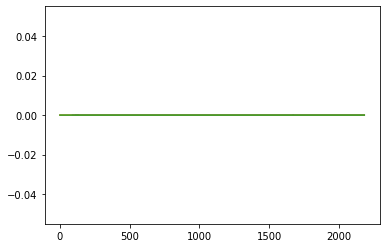

In [68]:
plt.plot(merge["Radial"] - merge["RAD_Lot"])
plt.plot(merge["Waterlevel"] - merge["W"])
plt.plot(merge["Temperature"] - merge["T"])

In [70]:
temporary = merge[["W", "T", "Radial", "Date"]]
#temporary= temporary[temporary["Date"] >= "04-01-2015"]
temporary["const"] = 1.0
temporary["trend"] = np.arange(0, len(temporary), 1)
print(len(temporary))
temporary = temporary.interpolate("ffill").fillna(method="backfill")



train = temporary[(temporary["Date"].dt.year < 2020)]
test = temporary[temporary["Date"].dt.year == 2020]
olsmod = sm.OLS(
    exog=train[["W", "T", "const", "trend"]],
    endog=train["Radial"].values,
)
olsres = olsmod.fit()


Deformation = olsres.predict(train[["W", "T", "const", "trend"]])
np.abs(test["Radial"].values - olsres.predict(test[["W", "T", "const", "trend"]])).mean()

2184


/tmp/ipykernel_4169966/1387186822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temporary["const"] = 1.0
/tmp/ipykernel_4169966/1387186822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temporary["trend"] = np.arange(0, len(temporary), 1)


0.725249702787556

In [ ]:
# Trend blah blah. First do results from 

In [50]:
train_b = train
test_b = test

In [51]:
# Sufficiently close id say. So now: Why is the baseline model from the search better?

In [52]:
combo = param_holder(
    p=0,
    d=0,
    q=0,
    f=0,
    ex=[[0], [0]],
    mean=[0, 0],
    decompose=0,
)

In [53]:
(train,
test,
max_data,
min_data,
trend,
seasonality,
test_trend,
test_seasonality) = (
full_preprocessing_pipeline(lot["Moehne"]["lot"], exogs["Moehne"], combo, model_search=False, normalization=False, outlier_filtering=False, interpolate=True)
)




model, trend_step = perform_modeling_linear(train[0]["Radial"], train[1], combo)
pred_one_step = forecast_test_linear(
    test[0]["Radial"], test[1], combo, model, trend_step
)

data = perform_modeling_linear(train[0]["Radial"], train[1], combo, return_temporary=True)
test_data = forecast_test_linear(
    test[0]["Radial"], test[1], combo, model, trend_step, return_temporary=True
)

pred_one_step.columns = ["Radial"]
Y, Y_hat = bring_to_original_range(
    test[0]["Radial"],
    pred_one_step["Radial"],
    max_data["Radial"] if  isinstance(max_data, pd.Series) else None, 
    min_data["Radial"] if  isinstance(max_data, pd.Series) else None, 
    trend,
    seasonality,
    lot["Moehne"]["lot"],
    "Radial",
)

np.mean(np.abs(Y_hat - Y))

0.7052397316746666

In [31]:
olsmod = sm.OLS(
    exog=data,
    endog=train[0]["Radial"].values,
)
olsres = olsmod.fit()


Deformation = olsres.predict(test_data)
np.abs(test[0]["Radial"].values - Deformation).mean()

0.7052397316746666

In [32]:
olsmod = sm.OLS(
    exog=data,
    endog=train[0]["Radial"].values,
)
olsres = olsmod.fit()


Deformation = olsres.predict(test_data)
np.abs(test[0]["Radial"].values - Deformation).mean()

0.7052397316746666

In [33]:
data

,W_0,T_0,const,trend
date,,,,
2015-04-01,213.44,4.1,1.0,0.000000
2015-04-02,213.51,4.7,1.0,0.000576
2015-04-03,213.56,6.0,1.0,0.001152
2015-04-04,213.52,4.2,1.0,0.001728
2015-04-05,213.50,4.3,1.0,0.002304
...,...,...,...,...
2019-12-27,208.60,3.0,1.0,0.997120
2019-12-28,208.70,0.0,1.0,0.997696
2019-12-29,208.78,2.2,1.0,0.998272


In [34]:
train_b

,W,T,Radial,Date,const,trend
0,213.44,4.1,3.372,2015-04-01,1.0,0
1,213.51,4.7,3.390,2015-04-02,1.0,1
2,213.56,6.0,3.426,2015-04-03,1.0,2
3,213.52,4.2,3.245,2015-04-04,1.0,3
4,213.50,4.3,3.313,2015-04-05,1.0,4
...,...,...,...,...,...,...
1726,208.60,3.0,-0.249,2019-12-27,1.0,1726
1727,208.70,0.0,-0.030,2019-12-28,1.0,1727
1728,208.78,2.2,0.114,2019-12-29,1.0,1728
1729,208.86,8.2,0.133,2019-12-30,1.0,1729


In [724]:
data["trend"]

date
2015-04-01    0.000000
2015-04-02    0.000576
2015-04-03    0.001152
2015-04-04    0.001728
2015-04-05    0.002304
                ...   
2019-12-27    0.997120
2019-12-28    0.997696
2019-12-29    0.998272
2019-12-30    0.998848
2019-12-31    0.999424
Name: trend, Length: 1736, dtype: float64

In [707]:
train_b["trend"].valuesdata["trend"] = 

ValueError: Length of values (1731) does not match length of index (1736)

In [706]:
data["trend"]

date
2015-04-01   NaN
2015-04-02   NaN
2015-04-03   NaN
2015-04-04   NaN
2015-04-05   NaN
              ..
2019-12-27   NaN
2019-12-28   NaN
2019-12-29   NaN
2019-12-30   NaN
2019-12-31   NaN
Name: trend, Length: 1736, dtype: float64

In [559]:

temporary = merge[["W", "T", "RAD_Lot", "Date"]]
temporary= temporary[temporary["Date"] >= "04-01-2015"]
temporary["const"] = 1.0
temporary["trend"] = np.arange(0, len(temporary), 1)
print(len(temporary))
temporary.dropna(inplace=True)
print(len(temporary))


train = temporary[(temporary["Date"].dt.year < 2020)]
test = temporary[temporary["Date"].dt.year == 2020]
olsmod = sm.OLS(
    exog=train[["W", "T", "const", "trend"]],
    endog=train["RAD_Lot"].values,
)
olsres = olsmod.fit()


Deformation = olsres.predict(train[["W", "T", "const", "trend"]])
np.abs(test["RAD_Lot"].values - olsres.predict(test[["W", "T", "const", "trend"]])).mean()

2097
2090


0.7041559995203002

In [560]:
train

,W,T,RAD_Lot,Date,const,trend
0,213.44,4.1,3.372,2015-04-01,1.0,0
1,213.51,4.7,3.390,2015-04-02,1.0,1
2,213.56,6.0,3.426,2015-04-03,1.0,2
3,213.52,4.2,3.245,2015-04-04,1.0,3
4,213.50,4.3,3.313,2015-04-05,1.0,4
...,...,...,...,...,...,...
1726,208.60,3.0,-0.249,2019-12-27,1.0,1726
1727,208.70,0.0,-0.030,2019-12-28,1.0,1727
1728,208.78,2.2,0.114,2019-12-29,1.0,1728
1729,208.86,8.2,0.133,2019-12-30,1.0,1729
